In [2]:
import sys

In [3]:
!{sys.executable} -m pip uninstall -y numpy pandas pandas-datareader
!{sys.executable} -m pip install numpy==1.23.5 pandas==1.5.3 pandas-datareader==0.10.0


Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
Found existing installation: pandas 1.5.3
Uninstalling pandas-1.5.3:
  Successfully uninstalled pandas-1.5.3
Found existing installation: pandas-datareader 0.10.0
Uninstalling pandas-datareader-0.10.0:
  Successfully uninstalled pandas-datareader-0.10.0
  Using cached numpy-1.23.5-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
  Using cached pandas-1.5.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.1 MB)
  Using cached pandas_datareader-0.10.0-py3-none-any.whl (109 kB)

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd

print(np.__version__)
print(pd.__version__)


1.23.5
1.5.3


In [5]:
import pandas_datareader as pdr
key="1877dbb9a56522ba7345ad7a1a9c26e2118f6894"

In [6]:
df = pdr.get_data_tiingo("GOOG", api_key=key)


/tmp/ipykernel_20757/2103459282.py:1: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only.
  df = pdr.get_data_tiingo("GOOG", api_key=key)


In [7]:

df.head()


close      high      low     open  \
symbol date                                                             
GOOG   2021-02-16 00:00:00+00:00  2121.90  2152.680  2104.36  2104.36   
       2021-02-17 00:00:00+00:00  2128.31  2133.660  2098.92  2100.00   
       2021-02-18 00:00:00+00:00  2117.20  2132.735  2103.71  2110.39   
       2021-02-19 00:00:00+00:00  2101.14  2130.530  2097.41  2119.27   
       2021-02-22 00:00:00+00:00  2064.88  2091.420  2062.14  2067.00   

                                   volume    adjClose     adjHigh      adjLow  \
symbol date                                                                     
GOOG   2021-02-16 00:00:00+00:00  1133838  105.298730  106.826180  104.428312   
       2021-02-17 00:00:00+00:00  1020252  105.616825  105.882317  104.158354   
       2021-02-18 00:00:00+00:00  1121855  105.065494  105.836414  104.396056   
       2021-02-19 00:00:00+00:00  1457612  104.268521  105.726992  104.083420   
       2021-02-22 00:00:00+00:00  1349856  102.469128  103.786168  102.333156   

                                     adjOpen  adjVolume  divCash  splitFactor  
symbol date                                                                    
GOOG   2021-02-16 00:00:00+00:00  104.428312   22676760      0.0          1.0  
       2021-02-17 00:00:00+00:00  104.211948   20405040      0.0          1.0  
       2021-02-18 00:00:00+00:00  104.727549   22437100      0.0          1.0  
       2021-02-19 00:00:00+00:00  105.168217   29152240      0.0          1.0  
       2021-02-22 00:00:00+00:00  102.574332   26997120      0.0          1.0

In [8]:
df.to_csv('GOOGLE.csv')

In [9]:
import pandas as pd
df=pd.read_csv('GOOGLE.csv')
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,GOOG,2021-02-16 00:00:00+00:00,2121.90,2152.680,2104.36,2104.36,1133838,105.298730,106.826180,104.428312,104.428312,22676760,0.0,1.0
1,GOOG,2021-02-17 00:00:00+00:00,2128.31,2133.660,2098.92,2100.00,1020252,105.616825,105.882317,104.158354,104.211948,20405040,0.0,1.0
2,GOOG,2021-02-18 00:00:00+00:00,2117.20,2132.735,2103.71,2110.39,1121855,105.065494,105.836414,104.396056,104.727549,22437100,0.0,1.0
3,GOOG,2021-02-19 00:00:00+00:00,2101.14,2130.530,2097.41,2119.27,1457612,104.268521,105.726992,104.083420,105.168217,29152240,0.0,1.0
4,GOOG,2021-02-22 00:00:00+00:00,2064.88,2091.420,2062.14,2067.00,1349856,102.469128,103.786168,102.333156,102.574332,26997120,0.0,1.0


In [10]:
df1=df.reset_index()['close']
df1

0       2121.90
1       2128.31
2       2117.20
3       2101.14
4       2064.88
         ...   
1251     324.40
1252     318.63
1253     311.33
1254     309.37
1255     306.02
Name: close, Length: 1256, dtype: float64

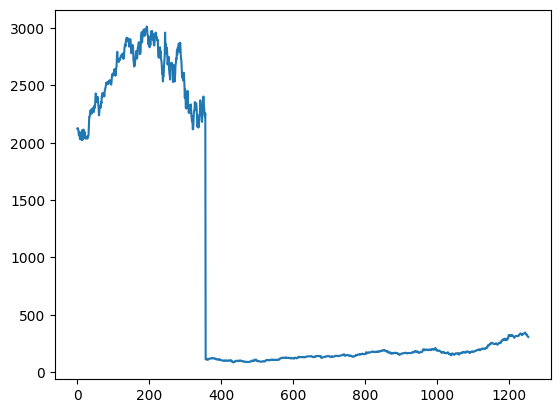

In [11]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [12]:
import numpy as np

In [13]:
df1

0       2121.90
1       2128.31
2       2117.20
3       2101.14
4       2064.88
         ...   
1251     324.40
1252     318.63
1253     311.33
1254     309.37
1255     306.02
Name: close, Length: 1256, dtype: float64

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))
print(df1)

[[0.69553928]
 [0.69772647]
 [0.69393556]
 ...
 [0.07774278]
 [0.077074  ]
 [0.07593092]]


In [15]:
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [16]:
training_size,test_size

(816, 440)

In [17]:
train_data

array([[0.69553928],
       [0.69772647],
       [0.69393556],
       [0.68845562],
       [0.67608311],
       [0.67812358],
       [0.68641856],
       [0.66464553],
       [0.66652222],
       [0.68175754],
       [0.67982284],
       [0.66305887],
       [0.6706953 ],
       [0.69098062],
       [0.66219218],
       [0.67192709],
       [0.67272212],
       [0.6931064 ],
       [0.67507311],
       [0.67663247],
       [0.68551433],
       [0.68502298],
       [0.66630384],
       [0.66868553],
       [0.66711252],
       [0.67201581],
       [0.66932019],
       [0.66908134],
       [0.66607522],
       [0.67303604],
       [0.67289614],
       [0.67736267],
       [0.70094756],
       [0.73090637],
       [0.7306334 ],
       [0.73913993],
       [0.7445175 ],
       [0.75149197],
       [0.74088355],
       [0.74514193],
       [0.74090061],
       [0.75517028],
       [0.75554562],
       [0.75712887],
       [0.7541364 ],
       [0.75402038],
       [0.74536372],
       [0.761

In [18]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100 
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [19]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [20]:
print(X_train.shape), print(y_train.shape)

(715, 100)
(715,)


(None, None)

In [21]:
print(X_test.shape), print(ytest.shape)

(339, 100)
(339,)


(None, None)

In [22]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)